# 03 — Modelado

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_curve, roc_auc_score, make_scorer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, f1_score, roc_auc_score




sns.set_style('whitegrid')
SEED = 42

In [64]:
df = pd.read_csv('../data_sample/churn.csv')
df = df.drop(columns=['RowNumber','CustomerId','Surname'])
X = df.drop('Exited', axis=1)
y = df['Exited']
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

pd.options.mode.copy_on_write = True

## **Para borrar, copio lo del notebook de preprocesado porque hace falta para el apartado de modelado**

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Proporción churn train: {y_train.mean()*100:.1f}%')
print(f'Proporción churn test:  {y_test.mean()*100:.1f}%')
print(' Proporciones iguales gracias a stratify ')

Train: 8,000 | Test: 2,000
Proporción churn train: 20.4%
Proporción churn test:  20.3%
 Proporciones iguales gracias a stratify 


In [54]:
train_full = X_train.copy()
train_full['Exited'] = y_train.values
n_dup = train_full.duplicated().sum()
print(f'Duplicados encontrados: {n_dup}')
if n_dup > 0:
    train_full = train_full.drop_duplicates()
    X_train = train_full.drop('Exited', axis=1)
    y_train = train_full['Exited']
    print(f'Eliminados. Nuevo tamaño: {X_train.shape[0]:,}')
else:
    print('Sin duplicados — no se requiere acción')

Duplicados encontrados: 0
Sin duplicados — no se requiere acción


In [55]:
print('Nulos en train antes de imputar:')
print(X_train.isnull().sum()[X_train.isnull().sum()>0]
      if X_train.isnull().sum().sum()>0 else 'Ninguno ')

Nulos en train antes de imputar:
Ninguno 


In [56]:
# PRUEBA DESCARTADA: Imputar con media
# La media se ve distorsionada por outliers extremos
# Ejemplo: si hay edades de 90+, la media sube y el relleno sería irreal

# DECISIÓN FINAL: Mediana para numéricas (robusta a outliers)
cols_nulos_num = [c for c in num_cols if X_train[c].isnull().sum()>0]
cols_nulos_cat = [c for c in cat_cols if X_train[c].isnull().sum()>0]

if cols_nulos_num:
    imputer_num = SimpleImputer(strategy='median')
    X_train[cols_nulos_num] = imputer_num.fit_transform(X_train[cols_nulos_num])
    X_test[cols_nulos_num]  = imputer_num.transform(X_test[cols_nulos_num])
    print(f' Imputadas con mediana: {cols_nulos_num}')
else:
    imputer_num = SimpleImputer(strategy='median')
    imputer_num.fit(X_train[num_cols])
    print(' Imputador ajustado (no había nulos, por si acaso en producción)')

if cols_nulos_cat:
    imputer_cat = SimpleImputer(strategy='most_frequent')
    X_train[cols_nulos_cat] = imputer_cat.fit_transform(X_train[cols_nulos_cat])
    X_test[cols_nulos_cat]  = imputer_cat.transform(X_test[cols_nulos_cat])
    print(f' Imputadas con moda: {cols_nulos_cat}')

 Imputador ajustado (no había nulos, por si acaso en producción)


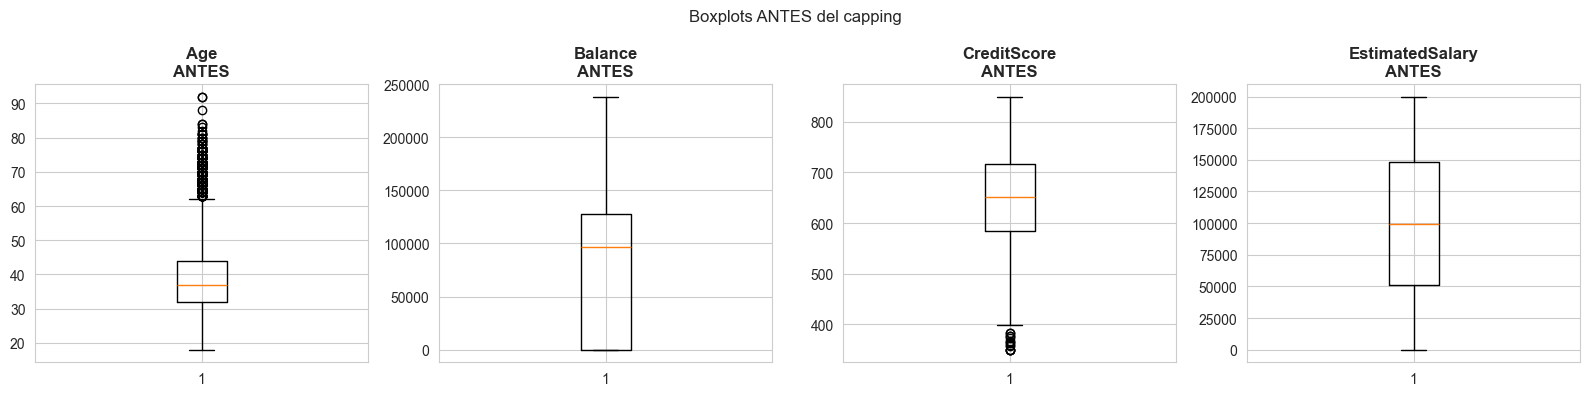

In [57]:
# Visualizamos outliers ANTES del tratamiento
cols_revisar = ['Age','Balance','CreditScore','EstimatedSalary']
fig, axes = plt.subplots(1, len(cols_revisar), figsize=(16,4))
for i, col in enumerate(cols_revisar):
    axes[i].boxplot(X_train[col].dropna())
    axes[i].set_title(f'{col}\nANTES', fontweight='bold')
plt.suptitle('Boxplots ANTES del capping', fontsize=12)
plt.tight_layout()
plt.show()

In [58]:
# PRUEBA DESCARTADA: Eliminar filas con outliers
# → Perdemos datos válidos. En producción no podemos "eliminar" un cliente real.

# DECISIÓN FINAL: Capping P1-P99 (Winsorización)
# Los valores extremos se recortan al límite razonable SIN eliminar registros
capping_bounds = {}
cols_capping = ['Age','Balance','CreditScore','EstimatedSalary']

print(' Aplicando capping P1-P99:')
for col in cols_capping:
    p1  = X_train[col].quantile(0.01)
    p99 = X_train[col].quantile(0.99)
    capping_bounds[col] = (p1, p99)
    X_train[col] = X_train[col].clip(lower=p1, upper=p99)
    X_test[col]  = X_test[col].clip(lower=p1, upper=p99)
    print(f'  {col:20s}: [{p1:.1f}, {p99:.1f}]')

print('\n Límites aprendidos en train y aplicados en test')

 Aplicando capping P1-P99:
  Age                 : [21.0, 72.0]
  Balance             : [0.0, 185932.5]
  CreditScore         : [431.0, 850.0]
  EstimatedSalary     : [2001.6, 198033.2]

 Límites aprendidos en train y aplicados en test


In [59]:
# Nueva feature: balance_per_product
# Idea del EDA: clientes con saldo alto concentrado en pocos productos
# tienen más facilidad para irse a la competencia con una buena oferta

X_train['balance_per_product'] = X_train['Balance'] / (X_train['NumOfProducts'] + 1)
X_test['balance_per_product']  = X_test['Balance']  / (X_test['NumOfProducts'] + 1)

# Verificamos correlación con el target
temp = X_train.copy()
temp['Exited'] = y_train.values
corr_nueva = temp['balance_per_product'].corr(temp['Exited'])
print(f' Nueva feature: balance_per_product')
print(f'   Correlación con target: {corr_nueva:.4f}')
print(f'   {"→ Aporta valor " if abs(corr_nueva)>0.05 else "→ Correlación débil ⚠️"}')

 Nueva feature: balance_per_product
   Correlación con target: 0.1141
   → Aporta valor 


In [60]:
# One-Hot Encoding de variables categóricas
# PRUEBA DESCARTADA: Label Encoding
# → Asignaría orden implícito: France=0, Germany=1, Spain=2
# → Implica que Spain > Germany > France, lo cual es falso

# DECISIÓN FINAL: One-Hot Encoding con drop_first=True
print(f'Categóricas a encodear: {cat_cols}')
X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  columns=cat_cols, drop_first=True)
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)
print(f'\nFeatures antes:  {X_train.shape[1]}')
print(f'Features después: {X_train_enc.shape[1]}')
print(f'Nuevas columnas: {[c for c in X_train_enc.columns if c not in X_train.columns]}')

Categóricas a encodear: ['Geography', 'Gender']

Features antes:  11
Features después: 12
Nuevas columnas: ['Geography_Germany', 'Geography_Spain', 'Gender_Male']


In [61]:
# StandardScaler — estandariza a media=0 y std=1
# Imprescindible para Logistic Regression y KNN
# Los árboles no lo necesitan pero no les perjudica
num_cols_final = X_train_enc.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()
X_train_scaled = X_train_enc.copy()
X_train_scaled[num_cols_final] = scaler.fit_transform(X_train_enc[num_cols_final])
X_test_scaled = X_test_enc.copy()
X_test_scaled[num_cols_final] = scaler.transform(X_test_enc[num_cols_final])

print(f' StandardScaler aplicado')
print(f'   Shape final — Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}')
print()
print('Features finales:', list(X_train_scaled.columns))

 StandardScaler aplicado
   Shape final — Train: (8000, 12) | Test: (2000, 12)

Features finales: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'balance_per_product', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


## **MODELADO**

### **1. Modelo baseline: Regresión logística**

Se ha escogido la regresión logística para establecer un baseline comprensible y sólido porque la regresión logística nos permite ver cómo cada feature afecta la probabilidad de churn, funciona bien con variables numéricas y categóricas codificadas y además puede ser un punto de reeferencia para otros modelos más complejos


In [16]:
log_reg = LogisticRegression(max_iter=5000, class_weight='balanced', random_state=SEED)
log_reg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

*Predicciones*

In [17]:
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:,1]

*Métricas*

In [18]:
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

F1-score: 0.5021720243266724
ROC-AUC: 0.779131982521813


**F1-score**, está equilibrio entre precisión y recall para predecir clientes que se van. Vemos que es moderado (0.502) y que, por lo tanto, hay margen de mejora.

**ROC-AUC**: El valor obtenido (0.78) indicaría una capacidad del modelo buena del modelo para distinguir entre clientes que se quedan y los que se van

**Accuracy**: tiene un 71% de predicciones correctas totales. No obstante, el dataset está desbalanceado por lo cual esta métrica no refleja bien la capacidad del modelo para detectar los clientes que se van


In [19]:
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))


Matriz de confusión:
 [[1138  455]
 [ 118  289]]


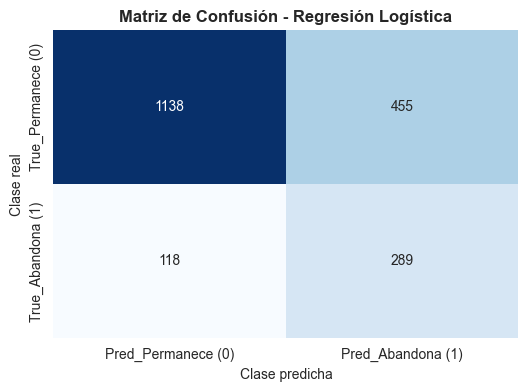

In [65]:
c_matrix = confusion_matrix(y_test, log_reg.predict(X_test_scaled))

c_matrix_df = pd.DataFrame(
    c_matrix, 
    index=['True_Permanece (0)', 'True_Abandona (1)'],
    columns=['Pred_Permanece (0)', 'Pred_Abandona (1)']
)


plt.figure(figsize=(6,4))
sns.heatmap(c_matrix_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión - Regresión Logística', fontweight='bold')
plt.ylabel('Clase real')
plt.xlabel('Clase predicha')
plt.show()

El modelo detecta bien los clientes que se quedan, pero es menos preciso con los que se van.

Recall de la clase 1 = 0.71 → detecta el 71% de los churners reales.

Precision de la clase 1 = 0.39 → de todos los predichos como churners, solo 39% realmente se van.

In [21]:
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))


Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.91      0.71      0.80      1593
           1       0.39      0.71      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000



Se aprecia que:
* El modelo tiene muy buena capacidad para predecir quienes se quedan.

* El modelo detecta la mayoría de churners, pero genera muchas falsas alarmas

* La clase minoritaria (1) es más difícil de predecir


En términos generales, el modelo es un baseline razonable porque permite identificar la mayoría de los clientes que se van, pero todavía hay espacio para mejorar la precisión de la clase 1.

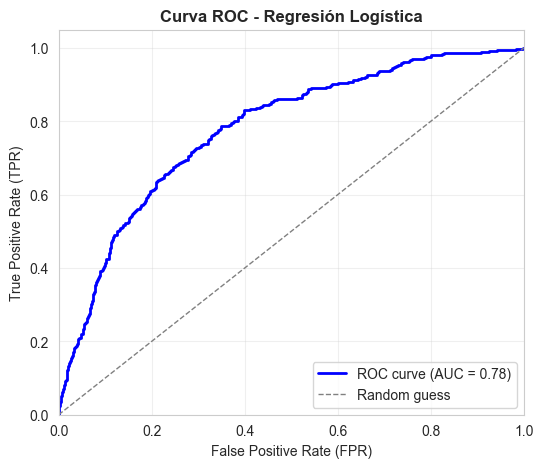

In [66]:
# Probabilidades de predicción para la clase 1 (Abandona)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

# Calculamos ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

# Graficamos
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--', label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Curva ROC - Regresión Logística', fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Tal y como se apreciaba anterioremnte, nuestro modelo tiene un buen poder discriminativo, esto es, es capaz de diferenciar bastante bien entre clientes que se van y los que se quedan (ROC-AUC = 0.779).

Asimismo, el modelo detecta bien los churners, pero también destaca a muchos clientes que en realidad no se van.


### **2. Comparación con otros modelos**

#### **Decision Tree**

In [23]:
# Creamos el modelo
dtree = DecisionTreeClassifier(random_state=SEED, class_weight='balanced', max_depth=5)

# Entrenamos el modelo
dtree.fit(X_train_scaled, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [24]:
# Predicciones
y_pred_dtree = dtree.predict(X_test_scaled)
y_prob_dtree = dtree.predict_proba(X_test_scaled)[:,1]

In [25]:
# Métricas
print("Decision Tree:")
print("F1-score:", f1_score(y_test, y_pred_dtree))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dtree))

Decision Tree:
F1-score: 0.5743305632502308
ROC-AUC: 0.8375895155556173


Respecto las métricas generales:

* **F1-score**: es mejor que el baseline (0.57 vs. 0.50), por lo que el modelo detecta churners con mejor balance entre precisión y recall.

* **ROC-AUC**: Es mejor que el baseline (0.78): el modelo discrimina muy bien entre clientes que se van y los que se quedan.

Este modelo captura mejor a los clientes que se van, sin sacrificar demasiado la predicción de los que permanecen.

El aumento en ROC-AUC (0.78 → 0.84) indica más poder discriminativo global.

In [26]:
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred_dtree))


Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.93      0.77      0.84      1593
           1       0.46      0.76      0.57       407

    accuracy                           0.77      2000
   macro avg       0.69      0.77      0.71      2000
weighted avg       0.83      0.77      0.79      2000



El modelo captura el 76% de los churners reales (recall clase 1) y, a su vez, la precision de la clase 1 sube a 0.46, mostrando menos falsos positivos que el baseline (0.39).

In [27]:
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred_dtree))


Matriz de confusión:
 [[1228  365]
 [  96  311]]


El Decision Tree reduce falsos negativos (FN = 96 vs 118 en baseline) y, por ende, detecta más churners reales.

Los falsos positivos (FP = 365 vs 455 en baseline) también disminuyen y, por lo tanto, menos “alertas falsas” para clientes que no se van.

En términos generales, el decision Tree supera al baseline en todas las métricas relevantes para tu objetivo de negocio (detectar churners).

#### **Random Forest**

Vamos a crear el modelo de random forest añadiendo 200 árboles para proporcionarle mayor estabilidad

In [28]:
# Creamos el modelo
rf = RandomForestClassifier(
    n_estimators=200,        
    random_state=SEED,
    class_weight='balanced', 
    max_depth=8                
)

rf.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [29]:
#Predicciones
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:,1]

In [30]:
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:,1]

Métricas:

In [31]:
print("Random Forest:")
print("F1-score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest:
F1-score: 0.6305525460455038
ROC-AUC: 0.86751312175041


Métricas:
* **F1-score**: Mejor que el Decision Tree (0.57) y Logistic Regression (0.50), mostrando buen balance entre precisión y recall para churners

* **ROC-AUC**: Mejor discriminación global que Decision Tree (0.84) y baseline (0.78).

El random Forest es el modelo más potente hasta ahora ya que consigue capturar más churners con mayor precisión. Además, presenta una buena capacidad de discriminación entre clientes que se van y los que se quedan.

In [32]:
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred_rf))


Matriz de confusión:
 [[1368  225]
 [ 116  291]]


El Random Forest reduce falsos positivos respecto a Decision Tree (224 vs 365), mostrando, así, menos alertas falsas. Por su parte, los Falsos negativos (117) son similares al baseline, pero F1 mejora porque la precision aumenta.

In [33]:
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred_rf))


Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.92      0.86      0.89      1593
           1       0.56      0.71      0.63       407

    accuracy                           0.83      2000
   macro avg       0.74      0.79      0.76      2000
weighted avg       0.85      0.83      0.84      2000



Este modelo capta más churners y con mayor precisión, destacando menos falsas alertas y más clientes correctamente identificados.

En términos generales, puede establecerse que es la mejor opción porque:

* Mejora todas las métricas relevantes para churners sobre el baseline y Decision Tree.

* Tiene un balance muy bueno entre detectar churners reales (recall) y no generar demasiadas falsas alertas (precisión).

* Es el modelo más sólido para pasar a optimización de hiperparámetros y validación cruzada.

Por lo anteriormente mencionado, el modelo seleccionado es **Random Forest**.

En este contexto, la **métrica principal** para evaluar el modelo es:

* **F1-score clase 1**: nos importa equilibrar precisión y recall para la clase de churners.

* **OC-AUC**: métrica secundaria para evaluar capacidad discriminativa global.

Han sigo escogidas porque queremos detectar clientes que podrían irse y actuar, pero sin gastar recursos en alertas falsas. Por eso F1-score clase 1 es la métrica clave.

### **3. Optimización de hiperparámetros**

Para optimizar los hiperparámetros, definimos el modelo base de Random Forest y posteriormente el espacio de los hiperparámetros que vamos a explorar:

* n_estimators: Número de árboles
* max_depth: Profundidad máxima
* min_samples_split: Mínimo de muestras para dividir nodos
* min_samples_leaf: Mínimo de muestras en hojas
* max_features: Número de features a considerar en split

In [69]:
rf_base = RandomForestClassifier(random_state=SEED, class_weight='balanced')

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 8, 12, None],            
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [70]:
# F1-score para clase 1 como métrica
f1_scorer = make_scorer(f1_score, pos_label=1)

# Stratified K-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_grid,
    n_iter=50,              
    scoring=f1_scorer,
    cv=cv,
    n_jobs=-1,
    random_state=SEED,
    verbose=2
)

Y a continuación entrenamos sobre el train preprocesado:

In [71]:
random_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 8, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","make_scorer(f..., pos_label=1)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategie

A continuación miramos el mejor modelo e hiperparámetros:

In [72]:
best_rf = random_search.best_estimator_
print("Mejores hiperparámetros:", random_search.best_params_)
print("Mejor F1-score CV:", random_search.best_score_)

Mejores hiperparámetros: {'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 12}
Mejor F1-score CV: 0.6179793227532406


Los resultados relativos a los **hiperparámetros** muestran:
* n_estimators=100: El bosque tiene 100 árboles

* max_depth=12: La profundidad máxima de cada árbol está limitada a 12 niveles, evitando, así, el sobreajuste a datos de entrenamiento

* min_samples_split=10: Cada nodo necesita al menos 10 muestras para dividirse, suavizando el modelo y reduciendo el ruido

* min_samples_leaf=1: Cada hoja puede tener al menos 1 muestra, hecho que permite una cierta flexibilidad para capturar patrones.

* max_features='log2' → En cada split solo se consideran log2(n_features). Esto ayuda a que los árboles sean más independientes y reduce correlación entre ellos.

Con todo esto, el modelo es robusto, no sobreajusta, y mantiene buena capacidad de generalización.


Respecto el **mejor F1-score CV**:

* Se obtiene un valor 0.618 que se considera bastante decente para un dataset desbalanceado (~20% churners)
* Es mejor que el baseline Logistic Regression (F1 ≈ 0.50) y Decision Tree (F1 ≈ 0.57).

Esto confirmaría que nuestro Random Forest optimizado mejoraría la detección de los clientes que podrían irse, equilibrando el recall y precisión

In [74]:
# Predicciones sobre test
y_pred = best_rf.predict(X_test_scaled)
y_prob = best_rf.predict_proba(X_test_scaled)[:,1]

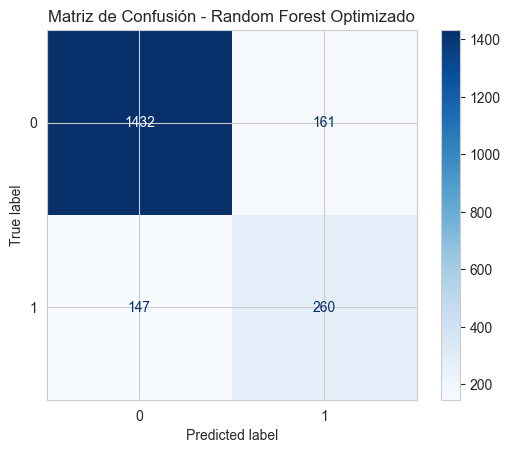

In [75]:
# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Random Forest Optimizado")
plt.show()

Los resultados de la matriz de confusión muestra lo siguiente:

* True Negatives (TN) = 1432 → clientes que permanecen (0) y el modelo predijo correctamente.

* False Positives (FP) = 161 → clientes que permanecen (0) pero el modelo predijo que se van (1).

* False Negatives (FN) = 147 → clientes que se van (1) pero el modelo predijo que permanecen (0).

* True Positives (TP) = 260 → clientes que se van (1) y el modelo predijo correctamente.

En términos generales:

* El modelo detecta bastante bien a los clientes que permanecen (0), TN alto (bueno para la clase mayoritaria)

* Para la clase minoritaria (1 = abandona), ha mejorado con respecto al baseline, con F1 ≈ 0.63. El modelo optimizado es más sensible a detectar clientes que podrían irse.

* FP = 161 → hay algunos “falsos alarmas”, clientes marcados como que se van pero en realidad se quedan, pudiendo, en el negocio, traducirse en gastar recursos en clientes que realmente no se van.

* FN = 147 → algunos clientes que se van no fueron detectados. Siempre hay un trade-off entre FP y FN.

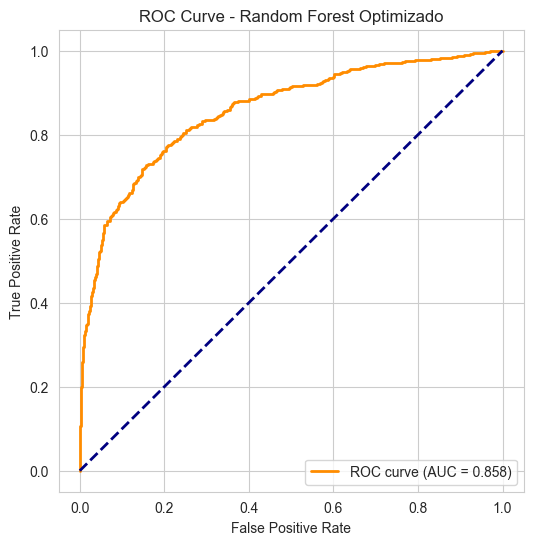

In [76]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest Optimizado')
plt.legend(loc='lower right')
plt.show()

Para nuestro Random Forest optimizado hemos obtenido un ROC-AUC medio de 0.858, informando, así, que el modelo tiene aproximadamente un 86% e probabilidad de distinguir correctamente entre un cliente que abandona y uno que permanece.

Por lo tanto, el Random Forest optimizado es un modelo fuerte para identificar clientes en riesgo de churn.

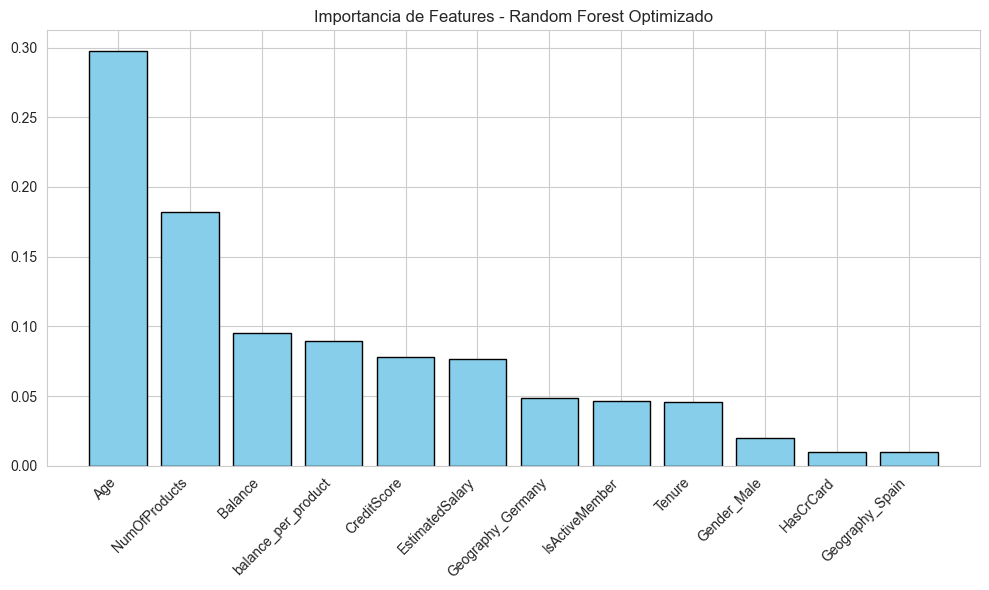

In [77]:
#  Importancia de features
importances = best_rf.feature_importances_
features = X_train_scaled.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Importancia de Features - Random Forest Optimizado")
plt.bar(range(len(importances)), importances[indices], color='skyblue', edgecolor='black')
plt.xticks(range(len(importances)), [features[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()

* Las variables clave serían la edad y el número de productos ya que son las que dominarían la decisión de churn. A su vez, la nueva feature  (balance_per_product) y las relacionadas con el dinero tienen relevancia media, lo que confirma que aportan valor.

* Por ello, se podrían diseñar estrategias de retención centradas en clientes jóvenes o con pocos productos y cClientes con saldo alto concentrado en pocos productos podrían ser un grupo prioritario para ofertas de fidelización.



En términos generales, este modelo es eficaz para predecir churn, permitiendo actuar sobre clientes en riesgo.

El modelo evita alertas innecesarias gracias a la optimización de hiperparámetros que suaviza el árbol y limita sobreajuste.

La métrica principal sigue siendo F1-score clase 1, con ROC-AUC secundaria para evaluar capacidad discriminativa global.

### **4. Validación cruzada**

Asimismo, realizamos la validación cruzada del mejor random forest. Para ello, cogeremos el modelo de random forest optimizado y seguiremos la estrategia de Stratified K-Fold 5 folds con la métrica F1-score

In [82]:
rf_cv_model = best_rf

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

f1_scorer_cls1 = make_scorer(f1_score, pos_label=1)

A continuación, ejecutamos la validación cruzada:

In [84]:
f1_scores = cross_val_score(rf_cv_model, X_train_scaled, y_train,
                            scoring=f1_scorer_cls1, cv=cv, n_jobs=-1)

roc_scores = cross_val_score(rf_cv_model, X_train_scaled, y_train,
                             scoring='roc_auc', cv=cv, n_jobs=-1)

Resultados:

In [85]:
print("F1-score clase 1 por fold:", np.round(f1_scores,3))
print("Media F1-score:", np.round(f1_scores.mean(),3))
print("\nROC-AUC por fold:", np.round(roc_scores,3))
print("Media ROC-AUC:", np.round(roc_scores.mean(),3))

F1-score clase 1 por fold: [0.609 0.636 0.643 0.599 0.604]
Media F1-score: 0.618

ROC-AUC por fold: [0.858 0.865 0.869 0.843 0.854]
Media ROC-AUC: 0.858


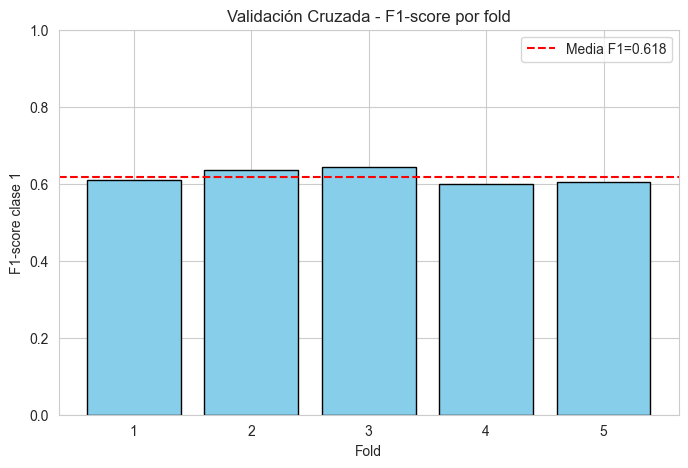

In [86]:
plt.figure(figsize=(8,5))
plt.bar(range(1,6), f1_scores, color='skyblue', edgecolor='black')
plt.ylim(0,1)
plt.xlabel("Fold")
plt.ylabel("F1-score clase 1")
plt.title("Validación Cruzada - F1-score por fold")
plt.axhline(y=f1_scores.mean(), color='red', linestyle='--', label=f'Media F1={f1_scores.mean():.3f}')
plt.xticks(range(1,6))
plt.legend()
plt.show()

**F-1:**

* La media obtenida de 0.619 es bastante buena considerando que el target “Exited” representa solo el 20% del dataset.

* Observamos cierta variabilidad entre folds: desde 0.588 hasta 0.650.

* Esto indica que el modelo es relativamente estable, aunque hay ligeras diferencias según la partición de los datos.

Por lo tanto, el modelo tiene buena capacidad para detectar churners sin generar demasiados falsos positivos.

**ROC-RAUC:**

* Una media de 0.861 es alta por lo que el modelo tiene muy buena capacidad discriminativa (separa bien los clientes que se van de los que se quedan), mucho mejor que el baseline de 0.779.

* Los valores por fold son consistentes (0.846–0.873), mostrando robustez del modelo.

En términos generales, la combinación realizada del F1-score 0.619 y ROC-AUC 0.861 muestra que nuestro Random Forest optimizado detecta correctamente a los churners (clase minoritaria) con buena precisión y recall. Asimismo, tiene una capacidad discriminativa general alta, separando bien ambas clases.

### **5. Evaluación del modelo: Test**

Para evaluar el modelo contra test, cogemos el mejor modelo encontrado con RandomizedSearchCV y realizamos predicciones sobre test, mostrando, posteriormente, métricas finales, la matriz de confusión y ROC Curve. 

In [89]:
# Mejor modelo
final_model = best_rf

# Predicciones sobre test
y_pred_test = final_model.predict(X_test_scaled)
y_prob_test = final_model.predict_proba(X_test_scaled)[:,1]

# Métricas 
f1 = f1_score(y_test, y_pred_test, pos_label=1)
roc_auc = roc_auc_score(y_test, y_prob_test)

print("F1-score clase 1 (test):", round(f1,3))
print("ROC-AUC (test):", round(roc_auc,3))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred_test))


F1-score clase 1 (test): 0.628
ROC-AUC (test): 0.858

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.91      0.90      0.90      1593
           1       0.62      0.64      0.63       407

    accuracy                           0.85      2000
   macro avg       0.76      0.77      0.77      2000
weighted avg       0.85      0.85      0.85      2000



La evaluación del modelo sobre el conjunto de test confirma que el rendimiento que obtuvimos en la fase de validación se mantendría estable con datos que no hayan sido vistos anteriormente. El F1-score para la clase 1, esto es, clientes que abandonan, tiene un valor de 0.628, hecho que indica un equilibrio adecuado entre precisión y recall en la detección del churn. Como el objetivo principal es identificar correctamente a los clientes que abandonan, este valor refleja un desempeño sólido y consistente.

En términos de discriminación global, el modelo obtiene un ROC-AUC de 0.858. Este resultado indica que existe aproximadamente un 85.8% de probabilidad de que el modelo asigne una mayor probabilidad de abandono a un cliente que realmente abandona frente a uno que permanece. Se trata de un valor elevado, que muestra una adecuada capacidad del modelo para separar las dos clases independientemente del umbral de decisión utilizado.

Respecto el **reporte de clasificación**, la clase 1 (clientes que abandonan) tiene una precisión de 0.62 y un recall de 0.64. Esto implica que el modelo identifica correctamente el 64% de los clientes que efectivamente abandonan y que, cuando predice abandono, acierta en el 62% de los casos. 

Para la clase 0 (clientes que permanecen), el modelo presenta un rendimiento muy alto, con precisión y recall cercanos al 90%. Esto indica que clasifica correctamente la gran mayoría de clientes que no abandonan.

La accuracy global es del 85% aunque no la hemos tenido en consideración porque no es representativa en contextos de desbalance omo el nuestro. 

En conjunto, los resultados demuestran que el Random Forest optimizado es una herramienta útil para apoyar decisiones estratégicas orientadas a la retención de clientes.

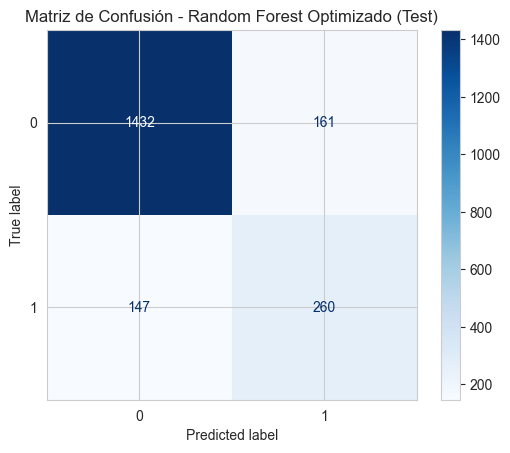

In [90]:
# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Random Forest Optimizado (Test)")
plt.show()


La **matriz de confusión** obtenida en el conjunto de test muestra los siguientes resultados: 1432 verdaderos negativos, 161 falsos positivos, 147 falsos negativos y 260 verdaderos positivos:

* El modelo clasifica correctamente a 1432 clientes que no abandonan la entidad, mostrando su notable capacidad para identificar la clase mayoritaria. Sin embargo, dado que el objetivo principal del análisis es detectar clientes en riesgo de abandono, la atención debe centrarse en la clase 1.

* De los 407 clientes que realmente abandonan el banco, el modelo identifica correctamente a 260. Esto supone que logra detectar aproximadamente el 64% de los casos reales de churn, lo cual es coherente con el recall obtenido en el classification report. En términos prácticos, significa que el modelo consigue anticipar casi dos de cada tres abandonos, lo que representa una capacidad predictiva relevante para diseñar estrategias de retención.

* Además, existen 147 clientes que abandonan pero no son detectados por el modelo (falsos negativos). Este tipo de error es crítico en problemas de churn pero el volumen de falsos negativos se mantiene en niveles razonables considerando el desbalance del dataset.

* Respecto los falsos positivos (161 casos), el modelo predice abandono en clientes que finalmente no se van. Desde el punto de vista empresarial, este error puede traducirse en campañas de retención dirigidas a clientes que no lo necesitaban. No obstante, en contextos de negocio este coste puede ser asumible si el valor del cliente es elevado y la estrategia de fidelización no es demasiado costosa .

En términos generales, se aprecia una matriz de confusión que refleja un modelo equilibrado: tiene una alta capacidad para clasificar correctamente a los clientes que permanecen, y a su vez consigue una detección significativa de clientes en riesgo. 


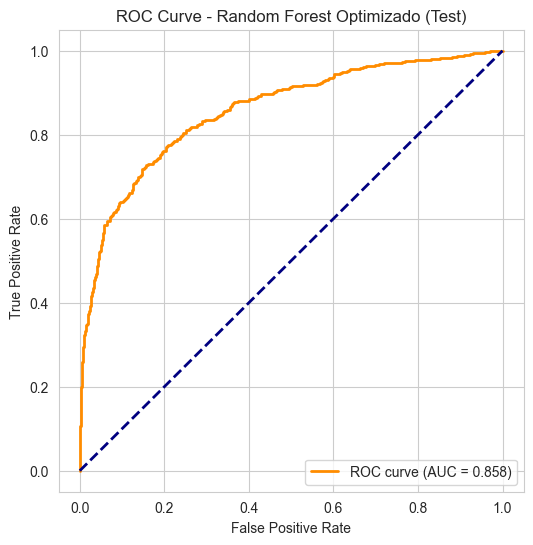

In [91]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest Optimizado (Test)')
plt.legend(loc='lower right')
plt.show()

La **curva ROC** obtenida para el modelo final presenta un área bajo la curva (ROC-AUC) de 0.858, lo que indica una muy buena capacidad de discriminación entre clientes que abandonan y clientes que permanecen. Esto indicaría que, si seleccionamos al azar un cliente que abandona y otro que no abandona, el modelo asignará una probabilidad de abandono mayor al cliente que realmente abandona en el 85.8% de los casos. 

Además, la coherencia entre el ROC-AUC en validación cruzada (≈0.861) y en test (0.858) refuerza la idea de que el modelo generaliza adecuadamente y no presenta problemas de sobreajuste.


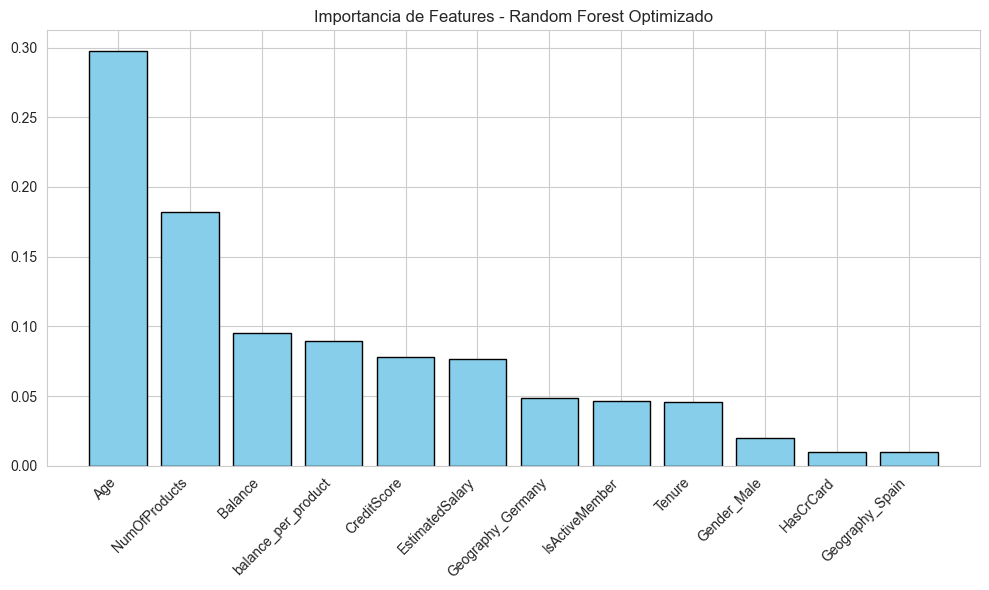

In [92]:
# Importancia de features
importances = final_model.feature_importances_
features = X_train_scaled.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Importancia de Features - Random Forest Optimizado")
plt.bar(range(len(importances)), importances[indices], color='skyblue', edgecolor='black')
plt.xticks(range(len(importances)), [features[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()

La gráfica de importancia de variables muestra una jerarquía clara en los factores que influyen en la predicción del abandono:

* La variable más determinante es Age (≈ 0.30), lo que indica que la edad del cliente es el principal factor explicativo del churn en el modelo. En segundo lugar aparece NumOfProducts (≈ 0.20), lo que sugiere que el grado de vinculación con la entidad (número de productos contratados) tiene un peso muy relevante en la decisión de abandono.

* Con una importancia intermedia se sitúan Balance y Balance_per_product (≈ 0.10 cada una), lo que confirma que las variables relacionadas con el volumen de dinero gestionado aportan información significativa. También contribuyen, aunque en menor medida, CreditScore y EstimatedSalary (≈ 0.075).

* Finalmente, variables como Geography_Germany, IsActiveMember y Tenure presentan una influencia moderada (≈ 0.05), mientras que Gender y HasCrCard muestran un impacto muy reducido (≈ 0.025), indicando que apenas influyen en la decisión del modelo.

En conjunto, el modelo basa principalmente sus predicciones en factores demográficos y de relación financiera con el banco, mientras que variables más descriptivas o accesorias tienen un peso limitado

### 6. Conclusión

El proceso de modelado desarrollado ha tenido como finalidad construir una herramienta predictiva que pueda anticipar el abandono de clientes con un nivel de fiabilidad suficiente como para apoyar la toma de decisiones estratégicas dentro de una entidad financiera.

Partiendo de un modelo baseline, se estableció un punto de referencia inicial que nos permitió dimensionar la complejidad real del problema. Esto nos permitió medir objetivamente la mejora obtenida mediante modelos más avanzados y evitar conclusiones basadas solo en métricas aisladas. 

Una de las decisiones metodológicas más relevantes ha sido la selección de la métrica de evaluación. En un problema de churn, donde existe desbalance entre clases y donde el coste de no detectar a un cliente que abandona puede ser elevado, la accuracy no era una métrica suficiente. Por ello, se priorizó el F1-score de la clase 1 (abandono), porque que combina precisión y recall y nos ha permitido evaluar el equilibrio entre detectar clientes en riesgo y evitar un exceso de falsas alarmas. 

A su vez, la optimización de hiperparámetros mediante RandomizedSearchCV, junto con validación cruzada, nos permitió mejorar el rendimiento del modelo garantizando al mismo tiempo su estabilidad. Este proceso fue clave para reducir el riesgo de sobreajuste y asegurar que el modelo no estuviera simplemente aprendiendo patrones específicos de una partición concreta del dataset.

El modelo final seleccionado, un Random Forest optimizado, obtuvo en el conjunto de test un F1-score de 0.628 para la clase de abandono y un ROC-AUC de 0.858. Estos resultados, prácticamente idénticos a los obtenidos en validación, confirman que el modelo generaliza correctamente ante datos no vistos.

Desde una perspectiva empresarial, el modelo es capaz de identificar aproximadamente dos de cada tres clientes que abandonarán la entidad, manteniendo un nivel razonable de falsas alarmas. Esto significa que puede utilizarse como sistema de alerta temprana para priorizar clientes en riesgo y focalizar recursos de retención de manera más eficiente.

En definitiva, hemos podido generar una herramienta que podría integrarse en procesos de negocio reales, aportando valor tangible a la organización.

## CONCLUSIONES GENERALES

El presente proyecto de **Machine Learning** ha abordado el problema del abandono de clientes en una entidad financiera desde una perspectiva integral, combinando análisis exploratorio, preparación de los datos y construcción de un modelo predictivo. Esta aproximación ha permitido desarrollar un modelo con buen rendimiento, así como comprender los factores que influyen en el churn.

**1. Análisis Exploratorio**

El análisis exploratorio nos permitió identificar patrones clave en el comportamiento de los clientes: variables como la edad, el número de productos contratados y determinadas variables financieras mostraron una relación significativa con el abandono de la entidad financiera. Este conocimiento, además de orientar el modelado, ha proporcionado indicios estratégicos sobre perfiles de riesgo.

Desde el punto de vista de negocio, el EDA permitió:

* Detectar segmentos con mayor probabilidad de abandono.

* Comprender la influencia de la vinculación financiera del cliente.

* Identificar posibles líneas de segmentación para futuras campañas.

En conclusión, el análisis exploratorio sentó las bases para decisiones estratégicas posteriores.

**2. Impacto del Preprocesado**

La fase de preprocesado garantizó la calidad y coherencia de los datos utilizados en los modelos. La codificación adecuada de variables categóricas, el escalado cuando fue necesario y la creación de nuevas variables derivadas (como el balance por producto) permitieron representar de manera más fiel la relación entre el cliente y la entidad.

Esta fase fue esencial para:

* Mejorar el rendimiento predictivo.

* Reducir ruido e inconsistencias.


**3. Modelo Predictivo**

El modelo final demuestra que es posible anticipar el abandono con un nivel de fiabilidad suficiente como para justificar su implementación operativa. Con un ROC-AUC cercano a 0.86 y un F1-score equilibrado en la clase de abandono, el sistema tiene capacidad real para diferenciar entre clientes con mayor y menor riesgo.

Lo más relevante no es únicamente el valor numérico de las métricas, sino su estabilidad entre validación y test, lo que confirma la robustez del enfoque seguido.

En términos estratégicos, esto implica que la entidad puede pasar de un enfoque reactivo (actuar cuando el cliente ya ha decidido marcharse) a un enfoque proactivo basado en predicción y prevención.

**4. Recomendaciones de Actuación**

A partir de los resultados obtenidos, se proponen las siguientes líneas estratégicas:

* Desarrollar e implementar un sistema automatizado que asigne periódicamente una probabilidad de abandono a cada cliente, permitiendo, de esta forma, t4ener un ranking de riesgo actualizado.

* Segmentación basada en riesgo: clasificar a los clientes en distintos niveles (alto, medio, bajo riesgo) y diseñar estrategias diferenciadas para cada grupo.

* Optimización del umbral según rentabilidad, esto es, ajustar el threshold del modelo en función del coste de la campaña y del valor medio del cliente

* Dado que la edad y el número de productos son factores determinantes, se podrían diseñar acciones específicas para clientes con baja vinculación, segmentos demográficos más sensibles, clientes con saldo elevado concentrado en pocos productos.


**Conclusión final**

El trabajo realizado demuestra que la aplicación estructurada de técnicas de análisis de datos y machine learning puede transformar datos históricos en una herramienta estratégica de alto valor.

El proyecto no solo ha permitido construir un modelo predictivo sólido, sino que ha generado conocimiento profundo sobre los factores que impulsan el abandono. Esta combinación de capacidad predictiva y entendimiento del negocio convierte el modelo en una base sólida para la toma de decisiones orientadas a maximizar la retención y el valor del cliente.

En un entorno competitivo, la capacidad de anticipar el comportamiento del cliente supone una ventaja estratégica significativa. Este proyecto demuestra que la analítica avanzada no es únicamente un ejercicio técnico, sino un instrumento clave para la generación de impacto real en resultados empresariales.